In [2]:
import matplotlib.pyplot as plt

# 1. 读取图片
img = plt.imread("test.jpg")

# 2. 输出形状
print(img.shape)
print(type(img))

(183, 275, 3)
<class 'numpy.ndarray'>


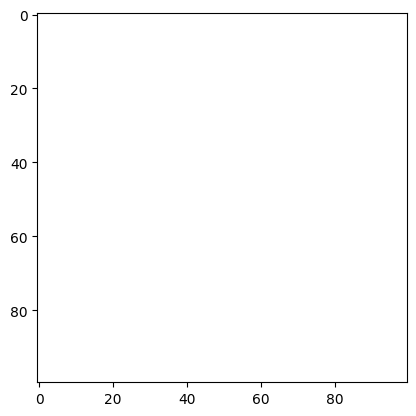

In [ ]:
# 0. 导包
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置矩阵
# (高，宽，通道) → (H, W, C)
white_img = np.full((100, 100, 3),255)
black_img = np.zeros((100, 100, 3))

# 2. 输出图像
plt.imshow(white_img)

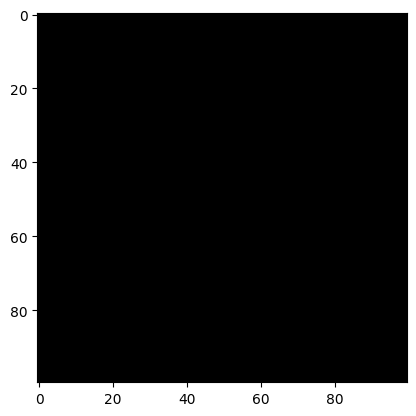

In [13]:

plt.imshow(black_img)

In [4]:
import torch
import torch.nn as nn

# 1. 将图片转换为tensor
data = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float()
print(data.shape)


# 2. 构建卷积层
conv = nn.Conv2d(in_channels=3, out_channels=5, kernel_size=3, stride=2, padding=0)

output = conv(data)
print(output.shape)

torch.Size([1, 3, 183, 275])
torch.Size([1, 5, 91, 137])


In [7]:
# 池化的计算案例
# 导包
import torch
import torch.nn as nn

# 1. 创建数据
# 单通道池化数据 (4,4)
X_1 = torch.tensor([[[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]]])

# 多通道池化数据 (2,4,4)
X_2 = torch.tensor([
        [[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]],
        [[10, 20, 30, 40], [50, 60, 70, 80], [90, 100, 110, 120], [130, 140, 150, 160]],
        ])

# 2. 创建池化层
pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)
pool_2 = nn.AvgPool2d(kernel_size=2, stride=2)

# 3. 池化计算
y_1 = pool_1(X_1)
y_2 = pool_2(X_2)

print(X_1.shape)

print(y_1.shape)
print('--------------------------------')
print(X_2.shape)
print(y_2.shape)


torch.Size([1, 4, 4])
torch.Size([1, 2, 2])
--------------------------------
torch.Size([2, 4, 4])
torch.Size([2, 2, 2])


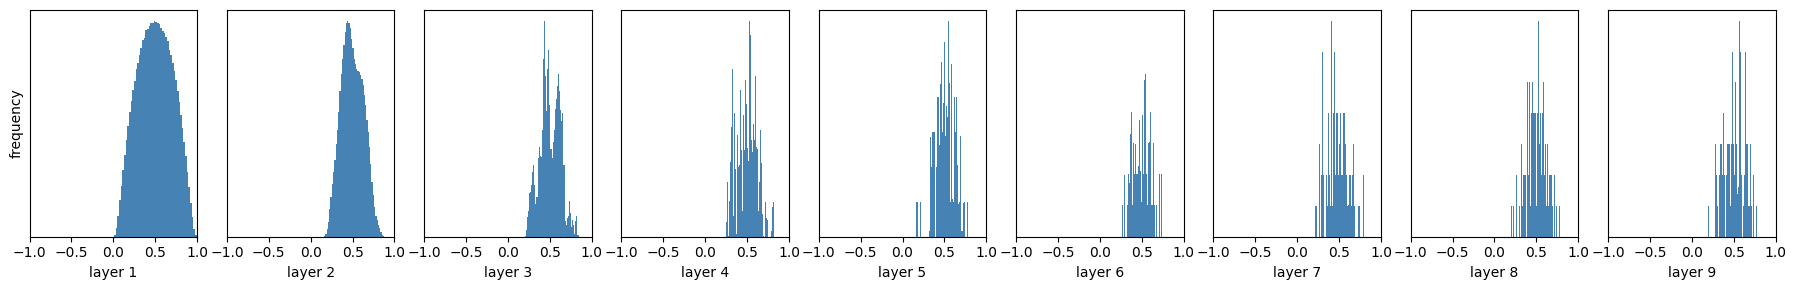

In [ ]:
import numpy as np  # 导入numpy用于数值计算
import matplotlib.pyplot as plt  # 导入matplotlib用于绘图

# 模拟深度神经网络的前向传播
def simulate_forward_pass(n_layers=9, n_samples=10000, activation='sigmoid'):  # 定义函数，设定层数、样本数量和激活函数类型
    layer_outputs = []  # 用于保存每一层的输出
    x = np.random.randn(n_samples, 100)  # 输入数据，服从标准正态分布，形状为(n_samples, 100)
    
    for i in range(n_layers):  # 遍历每一层
        # 权重初始化（可调整）
        W = np.random.randn(x.shape[1], 100) * 0.1  # 权重初始化，小方差（容易导致梯度消失）
        # W = np.random.randn(x.shape[1], 100) * np.sqrt(2.0/x.shape[1])  # He初始化（注释掉，可以切换）
        
        x = np.dot(x, W)  # 进行线性变换（全连接层操作）
        
        # 激活函数
        if activation == 'sigmoid':  # 如果激活函数为sigmoid
            x = 1 / (1 + np.exp(-x))  # 应用sigmoid函数
        elif activation == 'tanh':  # 如果激活函数为tanh
            x = np.tanh(x)  # 应用tanh函数
        elif activation == 'relu':  # 如果激活函数为relu
            x = np.maximum(0, x)  # 应用ReLU函数
        
        layer_outputs.append(x.flatten())  # 将当前层的输出拉平成一维后保存
    
    return layer_outputs  # 返回每一层的输出列表

# 绘制激活值分布
layer_outputs = simulate_forward_pass(n_layers=9, activation='sigmoid')  # 运行模拟前向传播，得到每层输出

fig, axes = plt.subplots(1, 9, figsize=(18, 3))  # 创建1行9列的子图
for i, (ax, output) in enumerate(zip(axes, layer_outputs)):  # 遍历每层的输出及对应的子图
    ax.hist(output, bins=50, color='steelblue', edgecolor='none')  # 绘制当前层输出的直方图
    ax.set_xlim(-1, 1)  # 设置x轴范围
    ax.set_xlabel(f'layer {i+1}')  # 设置x轴标签
    if i == 0:  # 仅首个子图显示y轴标签
        ax.set_ylabel('frequency')  # 设置y轴标签
    ax.set_yticks([])  # 隐藏y轴刻度

plt.tight_layout()  # 调整子图布局
plt.show()  # 显示所有直方图

# 梯度消失：使用 Sigmoid/Tanh 激活函数且权重初始化不当时，激活值逐渐集中在 0 附近，导致梯度越来越小。